In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

## Άσκηση - Διόρθωση σφαλμάτων σε ψηφιακές εικόνες

Τα συστήματα DVD αποθηκεύουν τις εικόνες που αποτελούν ένα video με μορφή σειρών από ψηφιακούς αριθμούς. Αν υπάρχει κάποιο πρόβλημα στο δισκάκι (ελαφρά γρατζουνιά, φθορά, σκόνη), το σύστημα του DVD προσπαθεί να "καθαρίσει" το δίσκο από το πρόβλημα χρησιμοποιώντας φίλτρα (δηλ. συστήματα διακριτού χρόνου που περιγράφονται ως εξισώσεις διαφορών!!!). Εδώ θα εξετάσουμε δυο τέτοια απλά συστήματα.
* Το πρώτο είναι το φίλτρο **κυλιόμενης μέσης τιμής (moving average)**. Συγκεκριμένα, θα χρησιμοποιήσουμε ένα τέτοιο φίλτρο τριών σημείων (3-point Moving Average - Κυλιόμενης Μέσης Τιμής τριών σημείων), το οποίο έχετε δει στις διαλέξεις (εδώ σε μια μη-αιτιατή version του - στο μάθημα είδαμε ένα όμοιο αλλά με αιτιατή κρουστική απόκριση):
$$ y[n] = \frac{1}{3}x[n+1] + \frac{1}{3}x[n] + \frac{1}{3}x[n-1] = \frac{1}{3}\sum_{k=-1}^{1} x[n-k] \tag{1}$$
* Το δεύτερο είναι ένα φίλτρο **μεσαίας τιμής (median filter)**, επίσης τριών σημείων:
$$ y[n] = \textrm{median}(x[n+1], x[n], x[n-1]) \tag{2}$$
το οποίο επιλέγει τη μεσαία τιμή (ταξινομώντας τα δείγματα εισόδου κατά αύξουσα σειρά). Παρατηρήστε ότι και τα δυο φίλτρα απαιτούν μόνο $3$ τιμές της εισόδου για να παράξουν μια τιμή της εξόδου.

i. Χρησιμοποιώντας την εντολή 

    A = mpimg.imread('Saturn.tif')

διαβάστε την εικόνα Saturn.tif που σας δίνεται στα αρχεία του εργαστηρίου. Δείτε τη με την εντολή 

    plt.imshow(A, cmap=plt.get_cmap('gray'))
    plt.show()

Υποθέστε ότι αυτή είναι μια καθαρή εικόνα από ένα DVD δίσκο.

## Απάντηση:

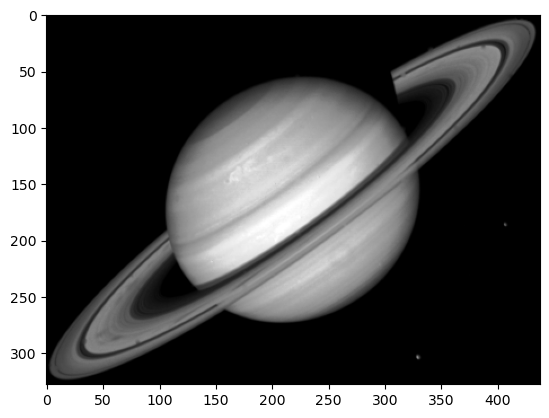

In [2]:
# Insert code here
A = mpimg.imread('./files/Saturn.tif')
plt.imshow(A, cmap=plt.get_cmap('gray'))
plt.show()

ii. Χρησιμοποιώντας την εντολή 

    B = mpimg.imread('NoiseSaturn.tif')

διαβάστε την εικόνα NoiseSaturn.tif. Δείτε τη με την εντολή 

    plt.imshow(B, cmap=plt.get_cmap('gray'))
    plt.show()

Ο θόρυβος που βλέπετε να έχει προστεθεί στην εικόνα ονομάζεται *salt and pepper noise* (θόρυβος "αλάτι και πιπέρι", λόγω της μορφής του). Υποθέστε ότι προήλθε από σφάλμα ανάγνωσης του δίσκου DVD λόγω φθοράς.

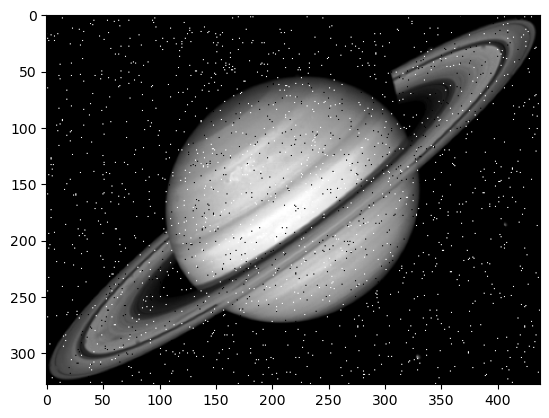

In [3]:
# Insert code here
B = mpimg.imread('./files/NoiseSaturn.tif')
plt.imshow(B, cmap=plt.get_cmap('gray'))
plt.show()

iii. Προσπαθήστε να εφαρμόσετε τα παραπάνω φίλτρα για να καθαρίσετε την εικόνα B. Σκεφτείτε ότι η εικόνα είναι ένας πίνακας $M$ x $N$, που σας είναι γνωστά. Κάθε τιμή του πίνακα αποτελεί ένα 
pixel της εικόνας. Εφαρμόστε τα φίλτρα σας κατά γραμμές ή κατά στήλες του πίνακα. Θεωρήστε ότι κάθε γραμμή (ή στήλη) αποτελεί ένα μονοδιάστατο σήμα $x[n]$ για τις παραπάνω εξισώσεις, το οποίο πρέπει να διατρέχετε σε τριάδες, με μετατόπιση ένα δείγμα κάθε φορά. Η έξοδος $y[n]$ θα είναι μια αριθμητική τιμή την οποία θα αποθηκεύσετε σε έναν πίνακα C, στην κατάλληλη θέση. Προσέξτε το type casting μεταξύ των εικόνων όταν τις απεικονίζετε (ο κώδικας παρακάτω βοηθά σε αυτό). 

Συνίσταται να ακολουθήστε τον παρακάτω κώδικα-σκελετό που αφορά το φίλτρο της Σχέσης (1) εφαρμοσμένο στις γραμμές της εικόνας:

    # Initialize C
    M = B.shape[0]
    N = B.shape[1]
    C = np.zeros((M,N))

    #  Cast to double for processing
    B = B.astype(float)

    #  Apply a moving average (MA) filter in every row
    for i in range(0,M):          # Process rows B[i,:]
         for j in range(1,N-1):     # Why from 1 to N-1 and not from 0 to N?
            x = # INSERT CODE HERE - use B matrix to get 
                # triads of data of row i
            y = # INSERT CODE HERE - use x vector to implement 
                # your filter
            C[i,j] = y              # Store result in another matrix

    #  Cast it to unsigned int
    C = C.astype(np.uint8)

    #  Show the result
    plt.figure
    plt.imshow(C, cmap=plt.get_cmap('gray'))
    plt.title('MA-filtered image in rows')
    plt.show()

Μπορείτε αν θέλετε να χρησιμοποιήσετε τις συναρτήσεις $\textrm{sum}$, $\textrm{mean}$, $\textrm{median}$, αλλά **μόνο αυτές**. Με όμοια φιλοσοφία φιλτράρετε κατά στήλες με το ίδιο φίλτρο (προσέξτε το indexing στους βρόχους επανάληψης), και στη συνέχεια κάνετε τα ίδια για το φίλτρο της Σχέσης (2).

**Για κάθε ένα από τα δυο φίλτρα:**

iv. Γράψτε κώδικα που παράγει δυο εικόνες του πίνακα C, μια που έχει προέλθει από φιλτράρισμα των *γραμμών* του πίνακα B, και μια που έχει προέλθει από φιλτράρισμα των *στηλών* του πίνακα B. 

Σχολιάστε τις παρατηρήσεις σας. Εν γένει, θα χαρακτηρίζατε και τα δυο φίλτρα ως αποδοτικά;

### Απάντηση:

**Φίλτρο κυλιόμενης μέσης τιμής τριών σημείων**

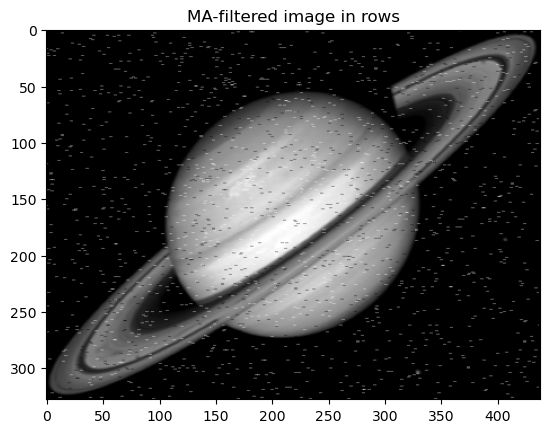

In [5]:
B = mpimg.imread('./files/NoiseSaturn.tif')

#  3-point Moving Average in rows

#  Initialize C
M = B.shape[0]
N = B.shape[1]
C = np.zeros((M,N))

#  Cast to double for processing
B = B.astype(float)

# Apply a moving average (MA) filter in every row
for i in range(0,M):       # Process rows B[i,:]
     for j in range(1,N-1):     # Why from 1 to N-2 and not from 0 to N-1?
        x = B[i, j-1:j+2]
        y = (1/3)*np.sum(x)
        C[i,j] = y;         # Store result in another matrix

#  Cast it to unsigned int
C = C.astype(np.uint8)

#  Show the result
plt.figure
plt.imshow(C, cmap=plt.get_cmap('gray'))
plt.title('MA-filtered image in rows')
plt.show()

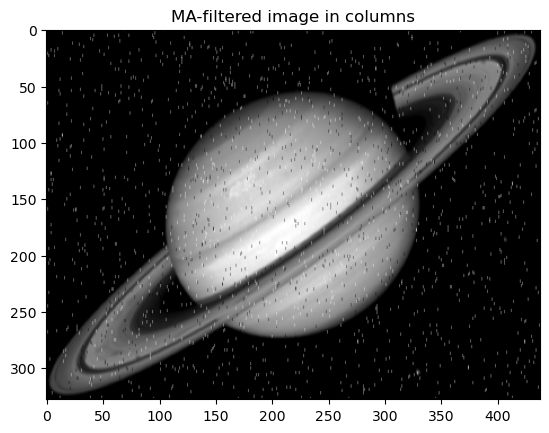

In [6]:
# 3-point Moving Average in columns

# Initialize C
M = B.shape[0]
N = B.shape[1]
C = np.zeros((M,N))
# Cast to double for processing
B = B.astype(float)
# Apply a moving average (MA) filter in every column
for j in range(0,N):          # Process columns B[:,j]
     for i in range(1,M-1):     # Why from 1 to M-2 and not from 0 to M-1?
        x = B[i-1:i+2, j]
        y = (1/3)*np.sum(x)
        C[i,j] = y              # Store result in another matrix
        
#  Cast it to unsigned int
C = C.astype(np.uint8)

#  Show the result
plt.figure
plt.imshow(C, cmap=plt.get_cmap('gray'))
plt.title('MA-filtered image in columns')
plt.show()

### Παρατηρήσεις:

#### Γράψτε εδώ τις παρατηρήσεις σας.

Παραπάνω φαίνονται τα παραγόμενα γραφήματα. Παρατηρούμε ότι στο φιλτράρισμα
των γραμμών εμφανίζονται "οριζόντιες αλλοιώσεις", ενώ στο φιλτράρισμα των στηλών εμφανίζονται
"κατακόρυφες αλλοιώσεις" στην εικόνα. Και στις 2 περιπτώσεις φαίνεται ότι η ένταση του θορύβου
σε σχέση με την αφιλτράριστη εικόνα έχει μειωθεί, αλλά η έκταση του θορύβου αυξάνεται. Ενώ δεν
υπάρχουν πλέον μεμονωμένα pixels με ακραίες τιμές (0 για μαύρο - 255 για άσπρο), δημιουργούνται
παραλληλόγραμμα που αποτελούνται από μερικά pixels που έχουν κάποια ενδιάμεση (πιο γκρίζα) τίμη
αλλά καταλαμβάνουν μεγαλύτερο χώρο στην εικόνα. Γενικά, θα λέγαμε ότι το φίλτρο κυλιόμενης μέσης
τιμής είναι αναποτελεσματικό.

**Φίλτρο μεσαίας τιμής τριών σημείων**

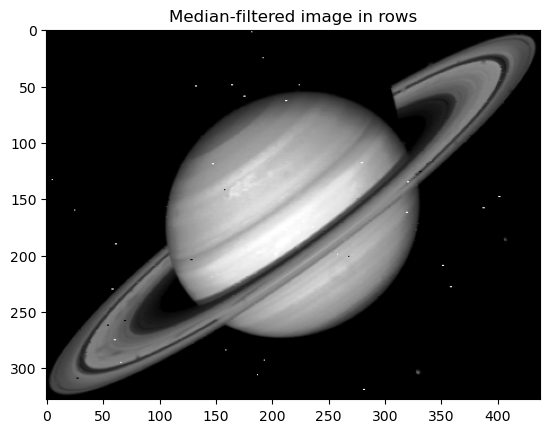

In [7]:
# 3-point Median filter in rows

# Initialize C
M = B.shape[0]
N = B.shape[1]
C = np.zeros((M,N))
# Cast to double for processing
B = B.astype(float)

#  Apply a median filter in every row
for i in range(0,M):       # Process rows B[i,:]
     for j in range(1,N-1):     # Why from 1 to N-2 and not from 0 to N-1?
        x = B[i, j-1:j+2]
        y = np.median(x)
        C[i,j] = y         # Store result in another matrix

#  Cast it to unsigned int
C = C.astype(np.uint8)

#  Show the result
plt.figure
plt.imshow(C, cmap=plt.get_cmap('gray'))
plt.title('Median-filtered image in rows')
plt.show()

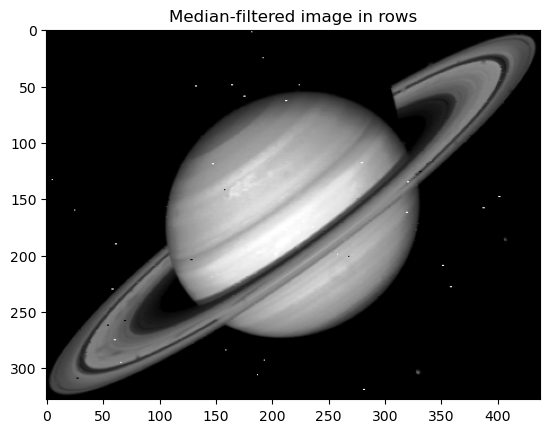

In [8]:
# 3-point Median filter in rows

# Initialize C
M = B.shape[0]
N = B.shape[1]
C = np.zeros((M,N))
# Cast to double for processing
B = B.astype(float)

#  Apply a median filter in every row
for i in range(0,M):       # Process rows B[i,:]
     for j in range(1,N-1):     # Why from 1 to N-2 and not from 0 to N-1?
        x = B[i, j-1:j+2]
        y = np.median(x)
        C[i,j] = y         # Store result in another matrix

#  Cast it to unsigned int
C = C.astype(np.uint8)

#  Show the result
plt.figure
plt.imshow(C, cmap=plt.get_cmap('gray'))
plt.title('Median-filtered image in rows')
plt.show()

### Παρατηρήσεις:

#### Γράψτε εδώ τις παρατηρήσεις σας.

Παραπάνω φαίνονται τα παραγόμενα γραφήματα. Παρατηρούμε ότι με το συγκεκριμένο
φίλτρο μειώνεται σημαντικά η έκταση του θορύβου (χωρίς να έχει απαλειφθεί τελείως ο θόρυβος), αλλά
η ένταση του είναι ίδια. Συνεχίζουν να υπάρχουν pixels με ακραίες τιμές (0 για μαύρο - 255 για άσπρο),
αλλά το πλήθος τους έχει μειωθεί σημαντικά. Γενικά, θα λέγαμε ότι **το φίλτρο κυλιόμενης μέσης τιμής
είναι αποτελεσματικό**.

v. Παραδώστε κώδικα που εφαρμόζει τα φίλτρα σας διαδοχικά (π.χ. εφαρμόστε ένα φίλτρο πρώτα σε γραμμές, και στο αποτέλεσμα που θα πάρετε εφαρμόστε το ίδιο φίλτρο ξανά κατά στήλες). Υλοποιήστε αυτή την προσέγγιση και με τα δυο φίλτρα. Παίρνετε καλύτερο αποτέλεσμα από πριν; Σχολιάστε.

### Απάντηση:

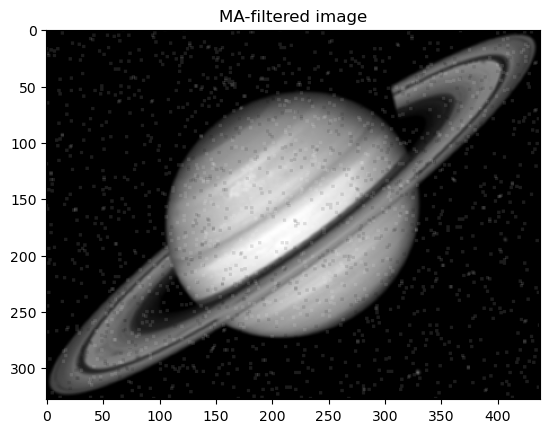

In [9]:
#  3-point Moving Average in rows and columns

#  Initialize C
M = B.shape[0]
N = B.shape[1]
C = np.zeros((M,N))
D = np.zeros((M,N))

#  Cast to double for processing
B = B.astype(float)

# Apply a moving average (MA) filter in every row
for i in range(0,M):       # Process rows B[i,:]
     for j in range(1,N-1):     # Why from 2 to N-1 and not from 1 to N?
        x = B[i, j-1:j+2]
        y = (1/3)*np.sum(x)
        C[i,j] = y        # Store result in another matrix

        
#  3-point Moving Average in columns
for j in range(0,N):       # Process columns B[:,j]
     for i in range(1,M-1):     # Why from 1 to M-2 and not from 0 to M-1?
        x = C[i-1:i+2, j]
        y = (1/3)*np.sum(x)
        D[i,j] = y         # Store result in another matrix
        
#  Cast it to unsigned int
D = D.astype(np.uint8)

#  Show the result
plt.figure 
plt.imshow(D, cmap=plt.get_cmap('gray'))
plt.title('MA-filtered image')
plt.show()

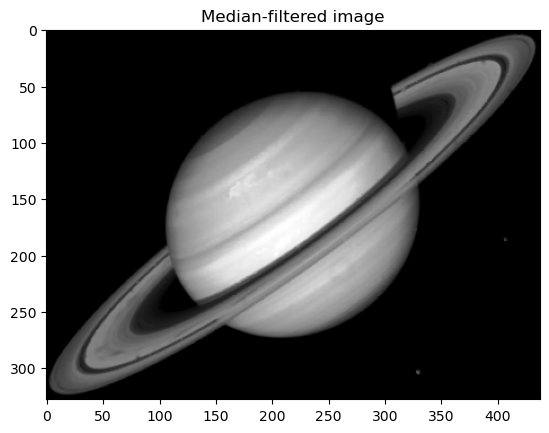

In [10]:
# 3-point Median filter in rows & columns

# Initialize C
M = B.shape[0]
N = B.shape[1]
C = np.zeros((M,N))
D = np.zeros((M,N))
# Cast to double for processing
B = B.astype(float)

#  Apply a median filter in every row
for i in range(0,M):       # Process rows B[i,:]
     for j in range(1,N-1):     # Why from 1 to N-2 and not from 0 to N-1?
        x = B[i, j-1:j+2]
        y = np.median(x)
        C[i,j] = y        # Store result in another matrix

#  3-point Median filter in columns
for j in range(0,N):       # Process columns C[:,j]
     for i in range(1,M-1):     # Why from 1 to M-2 and not from 0 to M-1?
        x = C[i-1:i+2, j]
        y = np.median(x)
        D[i,j] = y         # Store result in another matrix
       
# Cast it to unsigned int
D = D.astype(np.uint8)

#  Show the result
plt.figure 
plt.imshow(D, cmap=plt.get_cmap('gray'))
plt.title('Median-filtered image')
plt.show()

### Παρατηρήσεις:

#### Γράψτε εδώ τις παρατηρήσεις σας.

Παρατηρούμε ότι η φιλτραρισμένη με φίλτρο MA εικόνα είναι καλύτερη από τις εικόνες με φίλτρο ΜΑ
μόνο στις γραμμές/στήλες, καθώς η έκταση του θορύβου φαίνεται να μειώνεται. Όμως, ακόμα υπάρχει
αρκετός θόρυβος (με μικρότερη ένταση) και η εικόνα φαίνεται πιο θολή και "πιξελιασμένη". Θεωρούμε
ότι ακόμα και ένα φίλτρο median μόνο σε γραμμές/στήλες είναι καλύτερο από το φίλτρο MA. Το φίλτρο
median εφαρμοσμένο και σε γραμμές και σε στήλες έχει πολύ καλά αποτελέσματα (γενικά φαίνεται να
είναι λιγότερο ευαίσθητο σε outliers), αφού βλέπουμε ότι η αρχική εικόνα αποκαταστάθηκε πλήρως μετά
την εφαρμογή του!

---
---